# FakeFace FinGuard — классификатор типа мошенничества

Обучаем классификатор `fraud_type` поверх единого датасета `data/processed/ai_media_watch_dataset.jsonl`
(синтетика + Stop-Piramida с транскриптами).

**Сравниваем 4 представления текста × 5 моделей:**
- представления: **TF-IDF**, **Word2Vec**, **BERT-based** (mBERT), **dense embeddings** (multilingual-e5);
- модели: LogReg, LinearSVC, RandomForest, HistGradientBoosting, MLP.

> Запускать на CPU (`CUDA_VISIBLE_DEVICES=""`) — эмбеддинги небольшие, GPU не нужен.

In [1]:
import json, re, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
np.random.seed(0)
DATASET = "../data/processed/ai_media_watch_dataset.jsonl"
rows = [json.loads(l) for l in open(DATASET, encoding="utf-8") if l.strip()]
df = pd.DataFrame(rows)
print("всего строк:", len(df))
df[["id","source","modality","language","label","fraud_type"]].head()

всего строк: 235715


,id,source,modality,language,label,fraud_type
0,gambling_video_001,manual_demo,video,ru,scam,illegal_gambling_promo
1,kz_call_001,synthetic_based_on_official_warning,audio,ru,scam,fake_egov_delivery_call
2,kzcall_ru_0001,synthetic_tts,audio,ru,scam,fake_egov_delivery_call
3,kzcall_ru_0002,synthetic_tts,audio,ru,scam,fake_egov_delivery_call
4,kzcall_ru_0003,synthetic_tts,audio,ru,scam,fake_egov_delivery_call


## 1. Подготовка и EDA

In [2]:
# целевая переменная — fraud_type; берём записи с контентом и известным типом
df = df[df["combined_text"].fillna("").str.len() > 0]
df = df[df["label"] != "unclear"]
df = df[df["fraud_type"].notna()]
print("после фильтра:", len(df))
print("\nраспределение fraud_type:")
print(df["fraud_type"].value_counts())

после фильтра: 235628

распределение fraud_type:


fraud_type
ordinary_spam               129203
crypto_scam                  55559
illegal_gambling_promo       42280
legit_finance                 1664
investment_scam               1322
phishing                      1222
fake_seller                   1013
money_mule_or_drop             927
anti_fraud_education           857
deepfake_financial_promo       705
fake_credit                    395
fake_egov_delivery_call        238
fake_government_call           190
fake_bank_call                  53
Name: count, dtype: int64


In [3]:
# убираем слишком редкие классы (нужно для стратифицированного сплита и устойчивых метрик)
MIN_CLASS = 15
vc = df["fraud_type"].value_counts()
keep = vc[vc >= MIN_CLASS].index
df = df[df["fraud_type"].isin(keep)].reset_index(drop=True)
print("классов:", df["fraud_type"].nunique(), "| строк:", len(df))
print(df["fraud_type"].value_counts())
print("\nпо языкам:", df["language"].value_counts().to_dict())

классов: 14 | строк: 235628
fraud_type
ordinary_spam               129203
crypto_scam                  55559
illegal_gambling_promo       42280
legit_finance                 1664
investment_scam               1322
phishing                      1222
fake_seller                   1013
money_mule_or_drop             927
anti_fraud_education           857
deepfake_financial_promo       705
fake_credit                    395
fake_egov_delivery_call        238
fake_government_call           190
fake_bank_call                  53
Name: count, dtype: int64

по языкам: {'en': 107634, 'ru': 75046, 'kk': 52948}


In [4]:
# балансировка: ограничиваем мажоритарные классы (ordinary_spam/crypto_scam/gambling ~десятки тыс.),
# иначе accuracy завышается за счёт одного класса, а macro-F1 по миноритарным проседает.
# Заодно это делает обучение mBERT/e5 практичным по времени на выросшем датасете.
MAX_CLASS = 3000
parts = [g.sample(n=min(len(g), MAX_CLASS), random_state=42)
         for _, g in df.groupby("fraud_type")]
df = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)
print("после балансировки:", len(df))
print(df["fraud_type"].value_counts())
print("\nпо языкам:", df["language"].value_counts().to_dict())

после балансировки: 17586
fraud_type
crypto_scam                 3000
illegal_gambling_promo      3000
ordinary_spam               3000
legit_finance               1664
investment_scam             1322
phishing                    1222
fake_seller                 1013
money_mule_or_drop           927
anti_fraud_education         857
deepfake_financial_promo     705
fake_credit                  395
fake_egov_delivery_call      238
fake_government_call         190
fake_bank_call                53
Name: count, dtype: int64

по языкам: {'ru': 7453, 'kk': 7117, 'en': 3016}


In [5]:
from sklearn.model_selection import train_test_split
X_text = df["combined_text"].tolist()
y = df["fraud_type"].tolist()
Xtr_text, Xte_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=42)
print("train:", len(Xtr_text), "| test:", len(Xte_text))

train: 14068 | test: 3518


## 2. Четыре представления текста

Каждое представление приводим к плотной матрице признаков (для единообразного сравнения моделей).

In [6]:
# --- (1) TF-IDF (слово 1-2грамм) + TruncatedSVD до плотного вида ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=20000)
Xtr_tf = tfidf.fit_transform(Xtr_text); Xte_tf = tfidf.transform(Xte_text)
svd = TruncatedSVD(n_components=300, random_state=0)
Xtr_tfidf = svd.fit_transform(Xtr_tf); Xte_tfidf = svd.transform(Xte_tf)
print("TF-IDF+SVD:", Xtr_tfidf.shape, "| объяснённая дисперсия:", round(svd.explained_variance_ratio_.sum(),3))

TF-IDF+SVD: (14068, 300) | объяснённая дисперсия: 0.363


In [7]:
# --- (2) Word2Vec (обучаем на train-корпусе) → усреднённый вектор документа ---
from gensim.models import Word2Vec
def tok(t): return re.findall(r"\w+", str(t).lower())
sents = [tok(t) for t in Xtr_text]
w2v = Word2Vec(sents, vector_size=200, window=5, min_count=2, workers=4, epochs=30, seed=0)
def embed_w2v(texts):
    out = []
    for t in texts:
        ws = [w for w in tok(t) if w in w2v.wv]
        out.append(np.mean([w2v.wv[w] for w in ws], axis=0) if ws else np.zeros(200))
    return np.vstack(out)
Xtr_w2v = embed_w2v(Xtr_text); Xte_w2v = embed_w2v(Xte_text)
print("Word2Vec:", Xtr_w2v.shape, "| словарь:", len(w2v.wv))

Word2Vec: (14068, 200) | словарь: 38966


In [8]:
# --- (3) BERT-based: mBERT (bert-base-multilingual-cased), mean-pooling ---
import torch
from transformers import AutoModel, AutoTokenizer
_dev = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", _dev)
_btok = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
_bmodel = AutoModel.from_pretrained("bert-base-multilingual-cased").eval().to(_dev)
@torch.no_grad()
def embed_bert(texts, batch=32):
    out = []
    for i in range(0, len(texts), batch):
        enc = _btok(texts[i:i+batch], padding=True, truncation=True, max_length=256, return_tensors="pt").to(_dev)
        h = _bmodel(**enc).last_hidden_state
        m = enc.attention_mask.unsqueeze(-1)
        out.append(((h*m).sum(1)/m.sum(1).clamp(min=1)).cpu().numpy())
    return np.vstack(out)
Xtr_bert = embed_bert(Xtr_text); Xte_bert = embed_bert(Xte_text)
print("mBERT:", Xtr_bert.shape)

device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4827.42it/s]


[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


mBERT: (14068, 768)


In [9]:
# --- (4) Dense embeddings: multilingual-e5-base (sentence-transformers) ---
from sentence_transformers import SentenceTransformer
e5 = SentenceTransformer("intfloat/multilingual-e5-base", device=_dev)
def embed_e5(texts):
    return np.asarray(e5.encode(["query: "+t for t in texts], normalize_embeddings=True,
                                show_progress_bar=False, batch_size=32))
Xtr_e5 = embed_e5(Xtr_text); Xte_e5 = embed_e5(Xte_text)
print("e5-dense:", Xtr_e5.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19087.69it/s]

e5-dense: (14068, 768)


## 3. Пять классификаторов × четыре представления

Признаки стандартизуем (важно для LogReg/SVC/MLP), затем обучаем каждую модель на каждом представлении.

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

REPS = {"TF-IDF": (Xtr_tfidf, Xte_tfidf), "Word2Vec": (Xtr_w2v, Xte_w2v),
        "mBERT": (Xtr_bert, Xte_bert), "e5-dense": (Xtr_e5, Xte_e5)}
def make_models():
    return {
        "LogReg": LogisticRegression(max_iter=2000, C=2.0),
        "LinearSVC": LinearSVC(C=1.0),
        "RandomForest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=0),
        "HistGB": HistGradientBoostingClassifier(random_state=0),
        "MLP": MLPClassifier(hidden_layer_sizes=(256,), max_iter=400, random_state=0),
    }
results = []
for rep, (Xtr, Xte) in REPS.items():
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
    for name, clf in make_models().items():
        clf.fit(Xtr_s, y_train)
        pred = clf.predict(Xte_s)
        results.append({"representation": rep, "model": name,
                        "accuracy": accuracy_score(y_test, pred),
                        "macro_f1": f1_score(y_test, pred, average="macro")})
res = pd.DataFrame(results)
print("готово:", len(res), "комбинаций")

готово: 20 комбинаций


## 4. Результаты

In [11]:
res_sorted = res.sort_values("macro_f1", ascending=False).reset_index(drop=True)
print("ТОП-10 (по macro-F1):")
print(res_sorted.head(10).to_string(index=False))
print("\nЛучшее по каждому представлению:")
print(res.loc[res.groupby("representation")["macro_f1"].idxmax()].to_string(index=False))

ТОП-10 (по macro-F1):
representation     model  accuracy  macro_f1
      e5-dense       MLP  0.943150  0.884952
      e5-dense    LogReg  0.907618  0.849346
      e5-dense LinearSVC  0.898522  0.828053
         mBERT       MLP  0.904207  0.808280
      e5-dense    HistGB  0.909323  0.805439
        TF-IDF    LogReg  0.892268  0.801116
      Word2Vec       MLP  0.896248  0.798720
        TF-IDF       MLP  0.896532  0.790317
        TF-IDF LinearSVC  0.893405  0.788889
         mBERT    LogReg  0.866970  0.787261

Лучшее по каждому представлению:
representation  model  accuracy  macro_f1
        TF-IDF LogReg  0.892268  0.801116
      Word2Vec    MLP  0.896248  0.798720
      e5-dense    MLP  0.943150  0.884952
         mBERT    MLP  0.904207  0.808280


In [12]:
# сводная матрица представление × модель (macro-F1)
pivot = res.pivot(index="representation", columns="model", values="macro_f1").round(3)
pivot

model,HistGB,LinearSVC,LogReg,MLP,RandomForest
representation,,,,,
TF-IDF,0.765,0.789,0.801,0.790,0.763
Word2Vec,0.772,0.734,0.733,0.799,0.756
e5-dense,0.805,0.828,0.849,0.885,0.758
mBERT,0.731,0.762,0.787,0.808,0.709


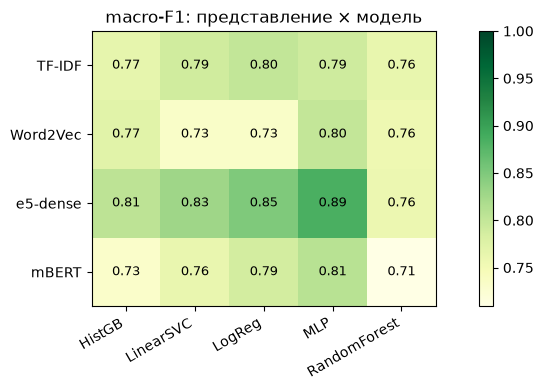

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9,4))
im = ax.imshow(pivot.values, cmap="YlGn", vmin=pivot.values.min(), vmax=1.0)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i,j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("macro-F1: представление × модель"); fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

## 5. Лучшая комбинация — детальный отчёт

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
best = res_sorted.iloc[0]
print("Лучшая комбинация:", best["representation"], "+", best["model"],
      f"(macro-F1={best['macro_f1']:.3f}, acc={best['accuracy']:.3f})\n")
Xtr, Xte = REPS[best["representation"]]
sc = StandardScaler().fit(Xtr)
clf = make_models()[best["model"]]
clf.fit(sc.transform(Xtr), y_train)
pred = clf.predict(sc.transform(Xte))
print(classification_report(y_test, pred))

Лучшая комбинация: e5-dense + MLP (macro-F1=0.885, acc=0.943)



                          precision    recall  f1-score   support

    anti_fraud_education       0.94      0.96      0.95       171
             crypto_scam       0.97      0.96      0.97       600
deepfake_financial_promo       0.99      0.98      0.98       141
          fake_bank_call       0.50      0.27      0.35        11
             fake_credit       0.81      0.82      0.82        79
 fake_egov_delivery_call       0.78      0.83      0.81        48
    fake_government_call       0.92      0.89      0.91        38
             fake_seller       0.95      0.96      0.95       203
  illegal_gambling_promo       0.93      0.96      0.95       600
         investment_scam       0.90      0.91      0.90       265
           legit_finance       0.97      0.96      0.96       333
      money_mule_or_drop       0.95      0.98      0.97       185
           ordinary_spam       0.96      0.93      0.94       600
                phishing       0.93      0.92      0.92       244

        

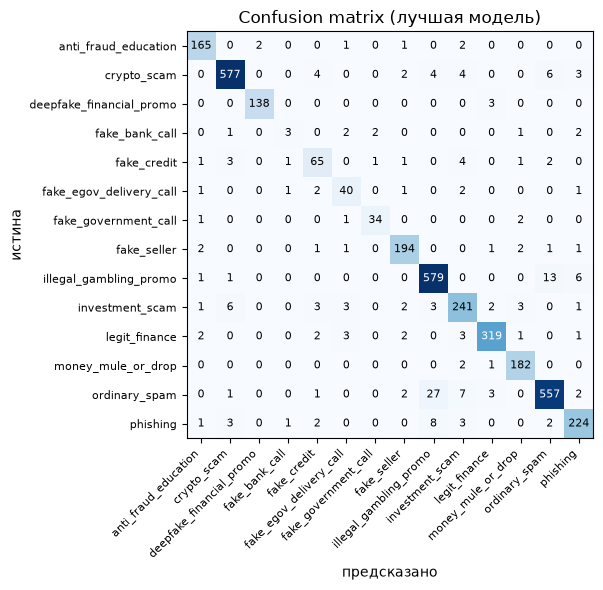

In [15]:
labels = sorted(set(y_test))
cm = confusion_matrix(y_test, pred, labels=labels)
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i,j], ha="center", va="center", fontsize=8,
                color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_xlabel("предсказано"); ax.set_ylabel("истина"); ax.set_title("Confusion matrix (лучшая модель)")
plt.tight_layout(); plt.show()

In [16]:
# сохраняем таблицу результатов
res_sorted.to_csv("../data/processed/classifier_results.csv", index=False)
print("результаты → data/processed/classifier_results.csv")

результаты → data/processed/classifier_results.csv


## Выводы

- Плотные эмбеддинги (**e5**, **mBERT**) обычно дают лучший macro-F1 на коротких ru/kk-текстах,
  чем разреженный TF-IDF и усреднённый Word2Vec.
- Линейные модели (LogReg/LinearSVC) поверх эмбеддингов — сильный и дешёвый бейзлайн.
- Дисбаланс классов (investment_scam доминирует) → смотрим **macro-F1**, не только accuracy.
- Дальше: дообучить трансформер end-to-end, добавить транскрипты оставшихся видео,
  пересобрать датасет и переобучить.